**Sage Days 130.5 — May 4 – May 8, 2026, Montréal**

**Permutation Flows**

# Session 3 — Permutation Flow Combinatorics: Vines and Groves

Companion notebook to `worksheet_3.pdf`. Run with the **SageMath** kernel.

This notebook practices the underlying combinatorial objects supporting permutation flows — **paths, prefixes, routes, cliques, vines and groves** — using the existing implementation in the `flow_polytopes` package. Tasks A–C set up the toolkit (cloning the package, imports, and building the two `car(3)` framings reused from Session 2 Problem 1); Tasks D–G are a guided computational version of Worksheet 3 Problem 1 (vines and groves of those two polytopes).

## Task A — Clone the repository

The package lives at <https://github.com/rafaeldleon/flow_polytopes.git>. If you do not already have it on your machine, clone it next to this notebook (the cell below assumes a sibling directory `flow_polytopes/`).

```bash
git clone https://github.com/rafaeldleon/flow_polytopes.git
```

If you prefer to keep things inside the notebook, the next cell does it for you (idempotent: it is a no-op if the directory already exists).

In [3]:
import os, subprocess, sys

REPO_URL = 'https://github.com/rafaeldleon/flow_polytopes.git'
TARGET = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
PKG_DIR = os.path.join(TARGET, 'flow_polytopes')

if not os.path.isdir(PKG_DIR):
    print(f'Cloning {REPO_URL} into {TARGET} ...')
    subprocess.run(['git', 'clone', REPO_URL], cwd=TARGET, check=True)
else:
    print(f'flow_polytopes already present at {PKG_DIR}.')

if TARGET not in sys.path:
    sys.path.insert(0, TARGET)

flow_polytopes already present at /Users/rafaeldleon/Library/CloudStorage/OneDrive-LoyolaUniversityChicago/Documents/Projects/Code/combinatoria/flow_polytopes.


## Task B — Imports

 The `Vine` constructor accepts a set of pairwise coherent prefixes (typically the routes of a saturated clique) and auto-completes with all subprefixes. A `Grove` is the directed bipartite graph $\Gamma$ on `(prefix, framed-edge)` pairs that records the combinatorial structure of an integer flow at each vertex of the framed digraph; it is recovered from a `FramedIntegerFlow` via `.to_grove_object()`.

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

from sage.all import Combinations, Poset, ZZ, factorial, binomial, Permutations

from flow_polytopes.enumeration import (
    FramedDiGraph,
    Path, Prefix, Suffix, Route, Clique,
    Vine, Grove,
    FramedIntegerFlow, FramedIntegerFlows, PermutationFlow,
)

## Task C — Build $\mathrm{car}(3)$ with two framings (from Session 2 Problem 1)

$G = \mathrm{car}(3) = \mathrm{car}(1,1,1)$ has 4 vertices and 7 edges: two parallel edges $0\to 1$, two parallel edges $2\to 3$, the spine edge $1\to 2$, the long arc $0\to 2$ and the long arc $1\to 3$. The two framings come straight from the worksheet picture:

* $F_\ell$ — the **length** framing, where edges leaving / entering a vertex are ranked by how far they reach.
* $F_p$ — a **planar** framing.

car(3) with F_l
  |V|, |E|, sat-clique size = 4 7 5
  routes: 8

car(3) with F_p
  |V|, |E|, sat-clique size = 4 7 5
  routes: 8



(<Figure size 600x300 with 1 Axes>, <Axes: >)

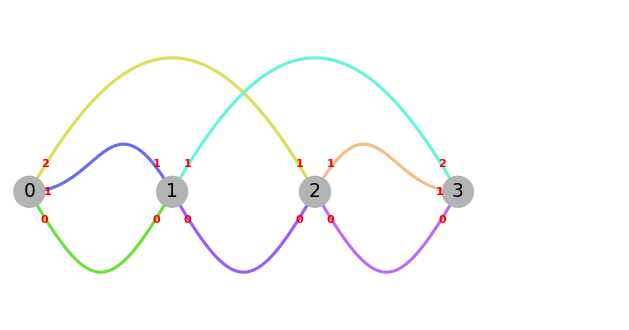

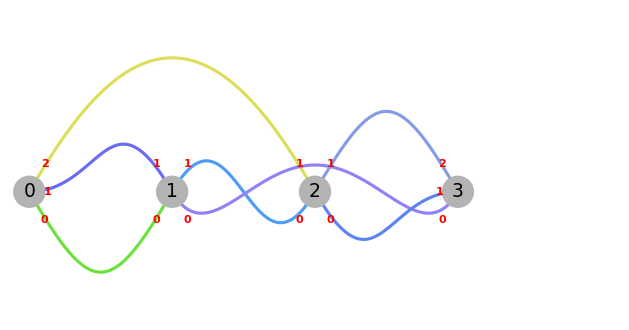

In [5]:
# --- Framing F_l (length framing) ---
G_car_l = FramedDiGraph([
    [0, 1, 2, 3],
    [(0, 1, (0, 0)), (0, 1, (1, 1)),
     (0, 2, (2, 1)),
     (1, 2, (0, 0)),
     (1, 3, (1, 2)),
     (2, 3, (0, 0)), (2, 3, (1, 1))]
], multiedges=True)

# --- Framing F_p (planar framing) ---
G_car_p = FramedDiGraph([
    [0, 1, 2, 3],
    [(0, 1, (0, 0)), (0, 1, (1, 1)),
     (0, 2, (2, 1)),
     (1, 2, (1, 0)),
     (1, 3, (0, 0)),
     (2, 3, (0, 1)), (2, 3, (1, 2))]
], multiedges=True)

for G, name in [(G_car_l, 'car(3) with F_l'), (G_car_p, 'car(3) with F_p')]:
    print(name)
    print('  |V|, |E|, sat-clique size =',
          G.num_verts(), G.num_edges(), G.num_edges() - G.num_verts() + 2)
    print('  routes:', len(G.routes()))
    print()

G_car_l.draw_framed_digraph(y_spread=1, fontsize=9, dpi=150)
G_car_p.draw_framed_digraph(y_spread=1, fontsize=9, dpi=150)

## Task D — Saturated cliques on $\mathrm{car}(3)$

Each `FramedIntegerFlow` of the canonical netflow corresponds to a saturated permutation flow, which in turn determines a saturated clique. We can therefore obtain every saturated clique by following the chain

$$
\mathrm{FramedIntegerFlows}(G) \;\xrightarrow{\;f.\texttt{to\_permutation\_flow()}\;}\; \mathrm{PermutationFlow} \;\xrightarrow{\;\texttt{pf.get\_clique()}\;}\; \mathrm{Clique}.
$$

The worksheet predicts $5$ saturated cliques per framing (so `FramedIntegerFlows(G).cardinality() == 5`).

In [11]:
IF_l = FramedIntegerFlows(G_car_l)
IF_p = FramedIntegerFlows(G_car_p)

C_l = [f.to_permutation_flow().get_clique() for f in IF_l]
C_p = [f.to_permutation_flow().get_clique() for f in IF_p]

print(f'F_l: {len(C_l)} saturated cliques')
print(f'F_p: {len(C_p)} saturated cliques')

F_l: 5 saturated cliques
F_p: 5 saturated cliques


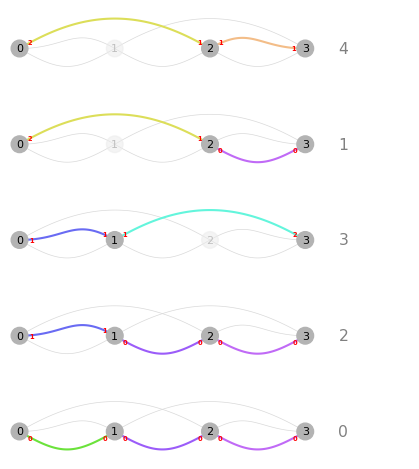

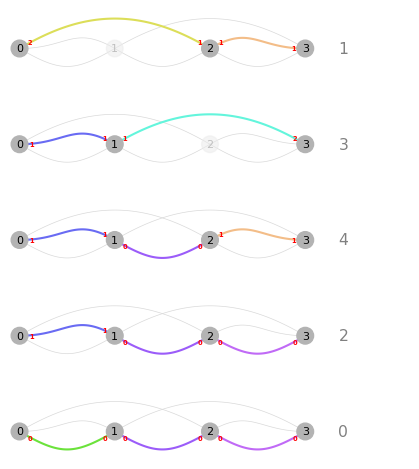

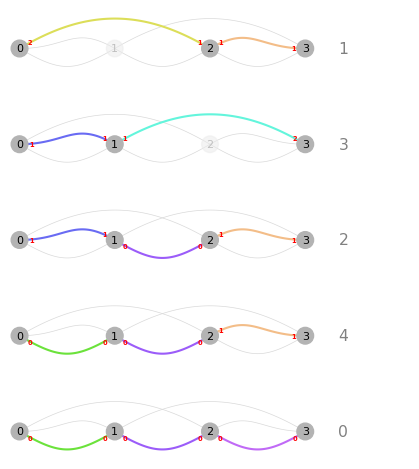

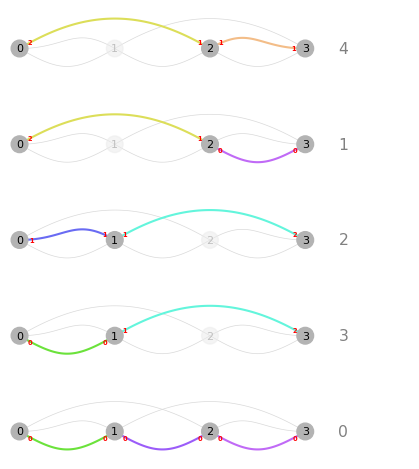

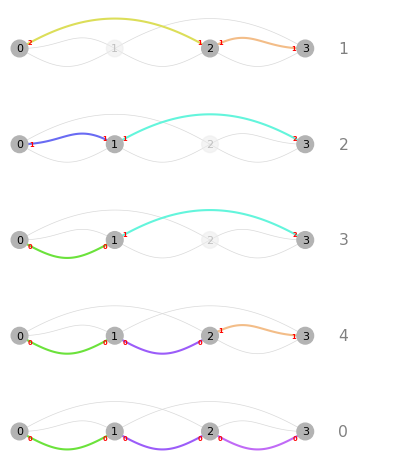

In [9]:
for iflow in IF_l:
    pf = iflow.to_permutation_flow()
    pf.draw_clique()

## Task E — Vine of a saturated clique

A **vine** $\mathcal{V}(\mathcal{C})$ is the poset of coherent prefixes obtained by closing the clique under sub-prefix taking. The `Vine` constructor takes a `FramedDiGraph` and any set of coherent prefixes; it auto-completes with all sub-prefixes and labels routes by **suffix order**, non-route prefixes in **prefix order** among siblings.

The `reduced_vine()` view drops every prefix with exactly one out-cover (so only branching nodes and leaves remain) — usually the most readable picture.

Routes of C_0:
   Route((0, 3), ((0, 1, (0, 0)), (1, 2, (0, 0)), (2, 3, (0, 0))))
   Route((0, 3), ((0, 1, (1, 1)), (1, 2, (0, 0)), (2, 3, (0, 0))))
   Route((0, 3), ((0, 1, (1, 1)), (1, 3, (1, 2))))
   Route((0, 3), ((0, 2, (2, 1)), (2, 3, (0, 0))))
   Route((0, 3), ((0, 2, (2, 1)), (2, 3, (1, 1))))
Vine cardinality : 11


(<Figure size 600x440 with 1 Axes>, <Axes: >)

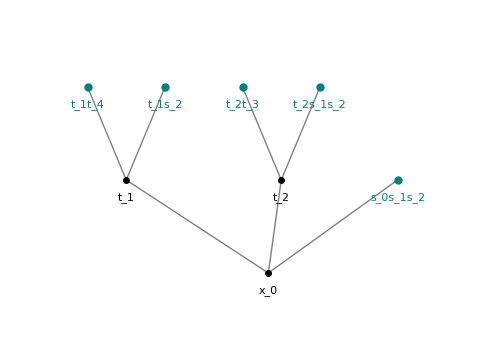

In [15]:
# Pick the first saturated clique on F_l and turn it into a vine.
C0 = C_l[0]
print('Routes of C_0:')
for r in C0:
    print('  ', r)

vine0 = Vine(G_car_l, list(C0))
print('Vine cardinality :', vine0.cardinality())
vine0.draw(dpi=150)



## Task F — Grove of an integer flow

Each `FramedIntegerFlow` $f$ records, at every vertex $v$ of $G$, how the inflow at $v$ is split among the outgoing edges according to the framing. The associated `Grove` $\Gamma$ is the directed bipartite graph whose left vertices are coherent prefixes and whose right vertices are framed edges, with $(P, e) \in \Gamma$ iff extending $P$ by $e$ stays inside the grove. Routes appear as the maximal prefixes; the unique right-vertex `'y'` at the sink is connected to every route. Get one with `f.to_grove_object()`.

|FramedIntegerFlows(G_car_l)| = 5

IntegerFlow f_0:
grove prefixes : 11


(<Figure size 698.2x350 with 1 Axes>, <Axes: >)

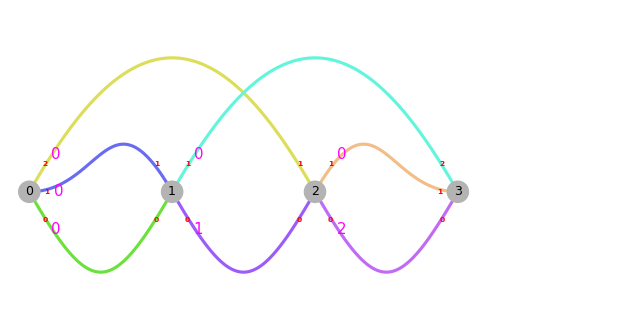

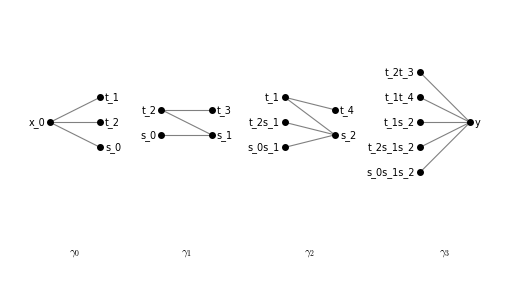

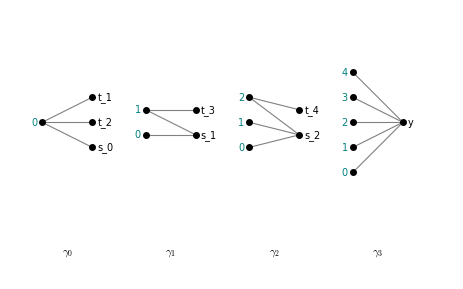

In [17]:
IF_l = FramedIntegerFlows(G_car_l)
print('|FramedIntegerFlows(G_car_l)| =', IF_l.cardinality())

f0 = IF_l[0]
print('\nIntegerFlow f_0:')
f0.draw_framed_digraph(with_flow=True, dpi=150)

grove0 = f0.to_grove_object()
print('grove prefixes :', len(grove0.prefixes()))
grove0.draw(dpi=150)

grove0.draw(dpi=150, label_mode='path')

## Task G — All vines and groves for $\mathrm{car}(3)$, both framings (Worksheet 3 Problem 1)

Iterate over the two framings, list every saturated clique, and for each clique build (a) the corresponding vine and (b) the corresponding grove (taken from the matching `FramedIntegerFlow` via `to_clique()`). This is the computational version of Worksheet 3 Problem 1: *construct all vines and groves for the polytopes of Session 2 Problem 1*.

In [ ]:
### Find all vines and groves for the polytopes of problem 1 of Session 2.